# Annotated fields: correct, wrong or missed

For one run and one sample, every field the person annotated is checked against what each
model wrote at the same place:

| Outcome | Meaning |
|---|---|
| **Correct** | the model's value matches the annotation |
| **Wrong** | the model wrote a different value there |
| **Missed** | the model wrote nothing there, or left it empty |

Fields the person left empty are not shown. The matrix has one panel per model; each row is
a kind of field, with the number annotated in brackets, and each cell is the share of that
row. The table underneath lists every annotated field.

**To look at another run or sample:** change `RUN` and `SAMPLE` in the next cell.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    import os
    os.chdir(Path.cwd().parent)

RUN    = "v4-sample14"                           # a folder under data/output/rda/runs/
SAMPLE = 14
RESULT = Path("data/output/rda/runs") / RUN / "evaluation_results.xlsx"
CHART  = Path("data/output/rda/runs") / RUN / f"field_matrix_sample{SAMPLE}.png"
MODELS = ["llama3.1-8b", "gemma4-e4b", "llama3.3-70b"]
OUTCOMES = ["Correct", "Wrong", "Missed"]

INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "text.color": INK,
    "axes.titlecolor": INK, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 220)


## 1. One outcome per annotated field and model


In [2]:
details = pd.read_excel(RESULT, sheet_name="details")
if "sample" in details:
    details = details[details["sample"] == SAMPLE]
details["model"] = details["model"].str.replace(":", "-")


def outcome(rows):
    """The evaluation writes one or two rows per annotated field; reduce them to one outcome."""
    if (rows.verdict == "Correct").any():
        return "Correct"
    wrote = rows[(rows.verdict == "Hallucinated") & (rows.reason != "empty where the reference has a value")]
    return "Wrong" if len(wrote) else "Missed"


def kind(path):
    """A readable name for a kind of field: dmp.dataset[3].distribution[0].host.title -> dataset > host > title"""
    p = re.sub(r"\[\d+\]", "", path.replace("dmp.", "", 1))
    return p.replace("distribution.", "").replace(".", " > ").replace("_", " ")


annotated = details[details["reference value"].notna()]
fields = (annotated.groupby(["field", "model"]).apply(outcome, include_groups=False)
          .rename("outcome").reset_index())
fields["kind"] = fields["field"].map(kind)
values = annotated.drop_duplicates("field").set_index("field")["reference value"]
wrote = (annotated[annotated["model value"].notna()]
         .drop_duplicates(["field", "model"]).set_index(["field", "model"])["model value"])

models = [m for m in MODELS if m in set(fields.model)]
n_fields = fields.field.nunique()
print(f"run {RUN}, sample {SAMPLE}: {n_fields} annotated fields, models: {', '.join(models)}")
display(fields.pivot_table(index="model", columns="outcome", values="field", aggfunc="count", fill_value=0)
        .reindex(index=models, columns=OUTCOMES, fill_value=0))


run v4-sample14, sample 14: 135 annotated fields, models: llama3.1-8b, gemma4-e4b, llama3.3-70b


outcome,Correct,Wrong,Missed
model,,,
llama3.1-8b,56,3,76
gemma4-e4b,9,11,115
llama3.3-70b,73,9,53


## 2. The matrix

Rows: the annotated fields, grouped into parts of the form, with how many were annotated in
brackets. Columns: for each model, how many of them it got correct (blue), wrong (red) or
missed (grey). The darker a cell, the larger its share of the row. Sized 16:9 for slides.


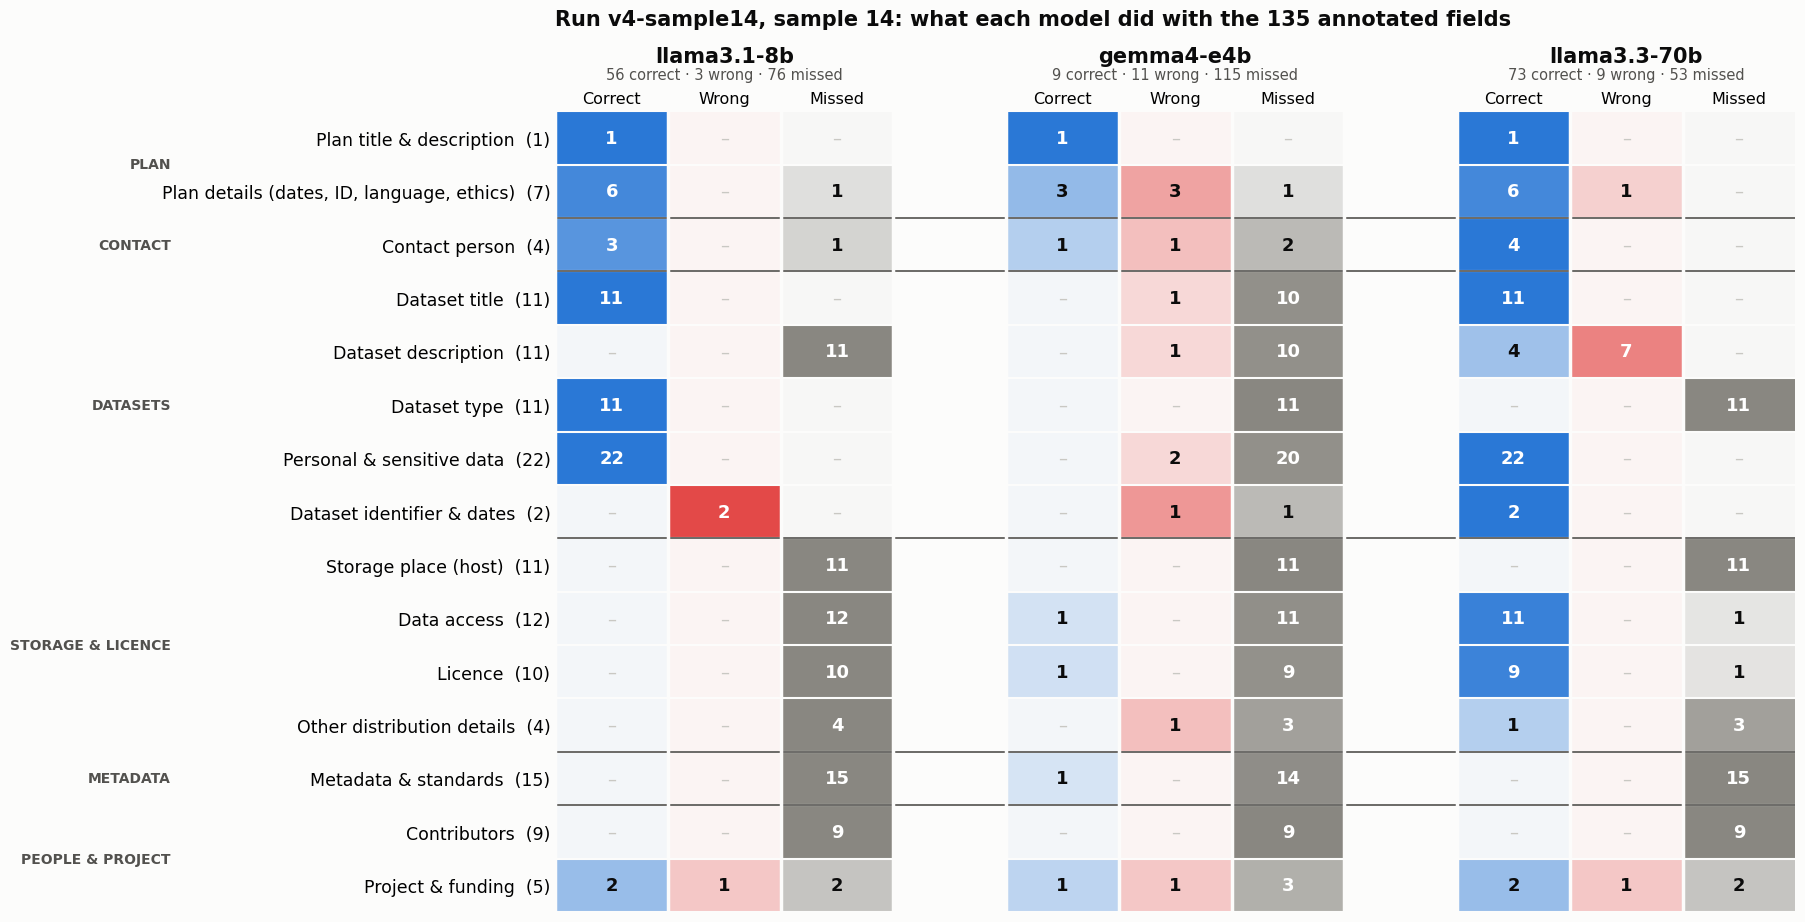

saved -> data\output\rda\runs\v4-sample14\field_matrix_sample14.png


In [3]:
import matplotlib.colors as mcolors

# Each annotated field -> (part of the form, row). Rows are kept few and in plain words.
def row_of(path):
    p = re.sub(r"\[\d+\]", "", path).replace("dmp.", "", 1)
    if p in ("title", "description"):                      return "Plan", "Plan title & description"
    if p.startswith("contact"):                            return "Contact", "Contact person"
    if p.startswith("contributor"):                        return "People & project", "Contributors"
    if p.startswith("project"):                            return "People & project", "Project & funding"
    if p.startswith("dataset.distribution.data_access"):   return "Storage & licence", "Data access"
    if p.startswith("dataset.distribution.host"):          return "Storage & licence", "Storage place (host)"
    if p.startswith("dataset.distribution.license"):       return "Storage & licence", "Licence"
    if p.startswith("dataset.distribution"):               return "Storage & licence", "Other distribution details"
    if p.startswith("dataset.metadata"):                   return "Metadata", "Metadata & standards"
    if p == "dataset.title":                               return "Datasets", "Dataset title"
    if p == "dataset.description":                         return "Datasets", "Dataset description"
    if p == "dataset.type":                                return "Datasets", "Dataset type"
    if p in ("dataset.personal_data", "dataset.sensitive_data"):
        return "Datasets", "Personal & sensitive data"
    if p.startswith("dataset"):                            return "Datasets", "Dataset identifier & dates"
    return "Plan", "Plan details (dates, ID, language, ethics)"


ROWS = [("Plan", "Plan title & description"), ("Plan", "Plan details (dates, ID, language, ethics)"),
        ("Contact", "Contact person"),
        ("Datasets", "Dataset title"), ("Datasets", "Dataset description"), ("Datasets", "Dataset type"),
        ("Datasets", "Personal & sensitive data"), ("Datasets", "Dataset identifier & dates"),
        ("Storage & licence", "Storage place (host)"), ("Storage & licence", "Data access"),
        ("Storage & licence", "Licence"), ("Storage & licence", "Other distribution details"),
        ("Metadata", "Metadata & standards"),
        ("People & project", "Contributors"), ("People & project", "Project & funding")]
COLOUR = {"Correct": "#2a78d6", "Wrong": "#e34948", "Missed": "#898781"}

fields[["section", "row"]] = fields["field"].map(row_of).tolist()
n_row = fields.drop_duplicates("field").groupby(["section", "row"]).size()
rows = [r for r in ROWS if r in n_row.index]                  # only rows this sample has
counts = (fields.groupby(["section", "row", "model", "outcome"]).size()
          .unstack(fill_value=0).reindex(columns=OUTCOMES, fill_value=0))

# Grid: per model three outcome columns, with an empty column between models
cols = []
for k, m in enumerate(models):
    cols += [(m, o) for o in OUTCOMES] + ([None] if k < len(models) - 1 else [])
surface = np.array(mcolors.to_rgb(SURFACE))
img = np.ones((len(rows), len(cols), 3)) * surface
for i, r in enumerate(rows):
    for j, c in enumerate(cols):
        if c is None:
            continue
        n = counts.loc[(*r, c[0]), c[1]] if (*r, c[0]) in counts.index else 0
        share = n / n_row[r]
        strength = 0.12 + 0.88 * share if n else 0.04
        img[i, j] = surface * (1 - strength) + np.array(mcolors.to_rgb(COLOUR[c[1]])) * strength

fig, ax = plt.subplots(figsize=(16, 0.52 * len(rows) + 2.6))
ax.imshow(img, aspect="auto")
for i, r in enumerate(rows):
    for j, c in enumerate(cols):
        if c is None:
            continue
        n = counts.loc[(*r, c[0]), c[1]] if (*r, c[0]) in counts.index else 0
        share = n / n_row[r]
        ax.text(j, i, str(n) if n else "–", ha="center", va="center", fontsize=13,
                fontweight="bold" if n else "normal",
                color=("white" if share > 0.5 else INK) if n else "#c9c8c3")

# Row labels with counts, section labels and separators
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([f"{r[1]}  ({n_row[r]})" for r in rows], fontsize=12.5)
ax.tick_params(length=0)
sections = list(dict.fromkeys(r[0] for r in rows))
for s in sections:                                             # section name centred on its rows, far left
    idx = [i for i, r in enumerate(rows) if r[0] == s]
    ax.text(-0.31, (idx[0] + idx[-1]) / 2, s.upper(), transform=ax.get_yaxis_transform(), ha="right",
            va="center", fontsize=10, fontweight="bold", color=MUTED)
    if idx[0] > 0:                                             # line between sections
        ax.axhline(idx[0] - 0.5, color=MUTED, linewidth=1.2)

# Column headers: outcome under each model name
ax.set_xticks([j for j, c in enumerate(cols) if c])
ax.set_xticklabels([c[1] for c in cols if c], fontsize=11.5)
ax.xaxis.tick_top()
for k, m in enumerate(models):
    first = cols.index((m, OUTCOMES[0]))
    t = counts.xs(m, level="model").sum()
    ax.text(first + 1, -1.35, f"{m}", ha="center", va="bottom", fontsize=15, fontweight="bold")
    ax.text(first + 1, -1.05, f"{t['Correct']} correct · {t['Wrong']} wrong · {t['Missed']} missed",
            ha="center", va="bottom", fontsize=10.5, color=MUTED)
for j, c in enumerate(cols):                                   # white gaps between cells
    ax.axvline(j - 0.5, color=SURFACE, linewidth=2.5)
for i in range(len(rows) + 1):
    ax.axhline(i - 0.5, color=SURFACE, linewidth=1.5, zorder=0.5)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(f"Run {RUN}, sample {SAMPLE}: what each model did with the {n_fields} annotated fields",
             loc="left", fontsize=15, pad=62)
fig.savefig(CHART, dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"saved -> {CHART}")


## 3. Every annotated field

One row per field the person annotated: the annotated value, each model's outcome, and,
when it was wrong, what the model wrote instead.


In [4]:
wide = fields.pivot(index="field", columns="model", values="outcome").reindex(columns=models)
wide.insert(0, "annotated value", values.reindex(wide.index).astype(str).str.slice(0, 60))
for m in models:
    wide[f"{m} wrote"] = [str(wrote.get((f, m), ""))[:45] if wide.loc[f, m] == "Wrong" else ""
                          for f in wide.index]
natural = lambda f: [int(x) if x.isdigit() else x for x in re.split(r"(\d+)", f)]
display(wide.loc[sorted(wide.index, key=natural)].reset_index())


model,field,annotated value,llama3.1-8b,gemma4-e4b,llama3.3-70b,llama3.1-8b wrote,gemma4-e4b wrote,llama3.3-70b wrote
0,dmp.contact.affiliation[0].name,Hakai Institute,Missed,Missed,Correct,,,
1,dmp.contact.contact_id[0].identifier,0000-0001-9317-0364,Correct,Wrong,Correct,,0000-0003-0644-4174,
2,dmp.contact.contact_id[0].type,orcid,Correct,Correct,Correct,,,
3,dmp.contact.name,Brett Johnson,Correct,Missed,Correct,,,
4,dmp.contributor[0].name,Brett Johnson,Missed,Missed,Missed,,,
5,dmp.contributor[0].role[0],Principal Investigator,Missed,Missed,Missed,,,
6,dmp.contributor[0].role[1],Data Manager,Missed,Missed,Missed,,,
7,dmp.contributor[1].name,Brian Hunt,Missed,Missed,Missed,,,
8,dmp.contributor[1].role[0],Principal Investigator,Missed,Missed,Missed,,,
9,dmp.contributor[2].name,Tim van der Stap,Missed,Missed,Missed,,,
